<a href="https://colab.research.google.com/github/rishabh7302/Machine-learning/blob/main/Random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [150]:
import seaborn as sns

In [151]:
df=sns.load_dataset("titanic")

In [152]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [153]:
df.shape

(891, 15)

In [154]:
df["survived"].value_counts()

,count
survived,
0,549
1,342


In [155]:
df["deck"].value_counts()

,count
deck,
C,59
B,47
D,33
E,32
A,15
F,13
G,4


In [156]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [157]:
#df[df['age'].isna()]
#df[df['age'].isnull()]

In [158]:
df.isnull().sum().sum()

np.int64(869)

# since there are 869 rows with NAN values so filling we done but generally we drop such columns with so many NAN values but in this we fill them

In [159]:
df['age']=df['age'].fillna(df['age'].median())


In [160]:
df['embarked']=df['embarked'].fillna(df['embarked'].mode()[0])
df['deck']=df['deck'].fillna(df['deck'].mode()[0])
df['embark_town']=df['embark_town'].fillna(df['embark_town'].mode()[0])

In [161]:
df.isnull().sum().sum()

np.int64(0)

In [162]:
x=df.drop('survived',axis=1)
y=df['survived']

In [163]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

## Now coverting the string columns to binary by LabelEncoder

In [164]:
from sklearn.preprocessing import LabelEncoder
ln=LabelEncoder()
cols=['sex','embarked','class','who','adult_male','deck','embark_town','alive','alone']
for col in cols:
    x_train[col]=ln.fit_transform(x_train[col])
    x_test[col]=ln.transform(x_test[col])


In [165]:
print(x_train.shape)
print(x_test.shape)

(712, 14)
(179, 14)


In [166]:
x_train.head()

,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
692,3,1,28.0,0,0,56.4958,2,2,1,1,2,2,1,1
481,2,1,28.0,0,0,0.0000,2,1,1,1,2,2,0,1
527,1,1,28.0,0,0,221.7792,2,0,1,1,2,2,0,1
855,3,0,18.0,0,1,9.3500,2,2,2,0,2,2,1,0
801,2,0,31.0,1,1,26.2500,2,1,2,0,2,2,1,0


In [167]:
x_train.values # numpy array nikal skte he dataframe me se

array([[ 3.,  1., 28., ...,  2.,  1.,  1.],
       [ 2.,  1., 28., ...,  2.,  0.,  1.],
       [ 1.,  1., 28., ...,  2.,  0.,  1.],
       ...,
       [ 3.,  0., 48., ...,  2.,  0.,  0.],
       [ 1.,  1., 47., ...,  2.,  0.,  1.],
       [ 1.,  1., 28., ...,  2.,  1.,  1.]])

In [168]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)


In [169]:
x_train

array([[ 0.82956755,  0.74242727, -0.11207776, ...,  0.58489231,
         1.26809251,  0.80034555],
       [-0.37094484,  0.74242727, -0.11207776, ...,  0.58489231,
        -0.788586  ,  0.80034555],
       [-1.57145722,  0.74242727, -0.11207776, ...,  0.58489231,
        -0.788586  ,  0.80034555],
       ...,
       [ 0.82956755, -1.34693328,  1.42338169, ...,  0.58489231,
        -0.788586  , -1.24946032],
       [-1.57145722,  0.74242727,  1.34660872, ...,  0.58489231,
        -0.788586  ,  0.80034555],
       [-1.57145722,  0.74242727, -0.11207776, ...,  0.58489231,
         1.26809251,  0.80034555]])

In [170]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100,max_depth=10)
rf.fit(x_train,y_train)


RandomForestClassifier(max_depth=10)

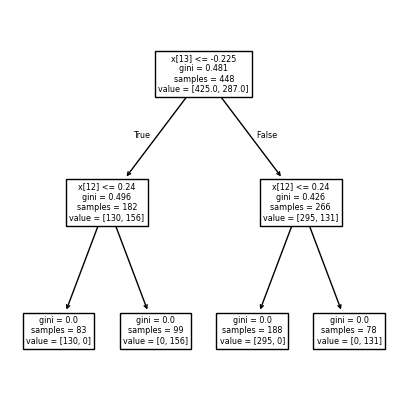

In [187]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(5,5))
plot_tree(rf.estimators_[1])
plt.show()


In [188]:
y_pred=rf.predict(x_test)

In [190]:
from sklearn.metrics import accuracy_score,classification_report
print(accuracy_score(y_test,y_pred)*100)
print(classification_report(y_test,y_pred))

100.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       110
           1       1.00      1.00      1.00        69

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



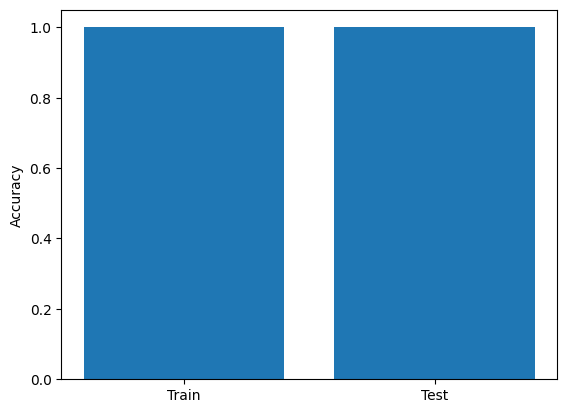

In [192]:
train_acc = rf.score(x_train, y_train)
test_acc = rf.score(x_test, y_test)

plt.bar(['Train', 'Test'], [train_acc, test_acc])
plt.ylabel('Accuracy')
plt.show()